## Implement VGG-16 - Training from Scratch

As a convenience, TensorFlow provides a model of the VGG-16 network within its `tf.keras.applications` module, so we can load the model directly without implementing the individual layers in Keras. We will instantiate a model of VGG-16 network architecture and train it from scratch on the types of balls dataset. This will be accomplished by instantiating the convolutional base of the network and chaining that together with a new dense classifier that we define.

We will see that training a relatively large model from scratch like VGG-16 can be time-consuming. Moreover, training it on a small dataset may lead to overfitting which limits validation accuracy.

### VGG-16 Architecture (ImageNet)
The VGG-16 architecture was originally designed and trained on ImageNet. Networks like VGG-16 consist of a convolutional base and a dense classifier. The dense classifier in VGG-16 consisted of two fully connected layers (each with 4,096 nodes) plus a final output layer containing 1,000 nodes for the 1,000 classes in ImageNet. Before we attempt to retrain this network for a different dataset we will need to replace the dense classifier.

<img src='https://opencv.org/wp-content/uploads/2022/03/c4_03_cnn_vgg_architecture.png' width=700><br/>

### VGG-16 Modified Architecture with New Dense Layer (Types of Balls)

To repurpose this network architecture for a different dataset, we need to replace the fully connected layers. In this example, we choose to include a single fully connected layer with 256 nodes, followed by an output layer of 10 nodes for the 10 classes in the Type of Balls dataset.

<img src='https://opencv.org/wp-content/uploads/2022/03/c4_03_cnn_vgg_architecture_balls.png'><br/>



In [1]:
import random
from dataclasses import dataclass
import numpy as np

import tensorflow as tf
import keras
from keras import layers
from keras.utils import image_dataset_from_directory

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
from sklearn.metrics import confusion_matrix

### Dataset and Training Configuaration

In [2]:
@dataclass
class DatasetConfig:
    IMG_WIDTH: int = 224
    IMG_HEIGHT: int = 224
    NUM_CHANNELS: int = 3
    BATCH_SIZE: int = 32
    NUM_CLASSES: int = 10
    DATA_ROOT_TRAIN: str = "../dataset/train"
    DATA_ROOT_VALID: str = "./../dataset/valid"


@dataclass
class TrainingConfig:
    EPOCHS: int = 21
    LEARNING_RATE: float = 0.001
    CHECKPOINT_PATH: str = "./classification_vgg16_scratch.keras"

### VGG-16 Convolution Base

The model may be loaded with pre-trained weights from ImageNet or initialized to random values. In this notebook, we will initialize the weights to random values to train the model from scratch.

In [3]:
input_shape = (
    DatasetConfig.IMG_HEIGHT,
    DatasetConfig.IMG_WIDTH,
    DatasetConfig.NUM_CHANNELS,
)

print("Building VGG16 model from scratch with random initial weights...")
convBase = keras.applications.vgg16.VGG16(
    include_top=False, input_shape=input_shape, weights=None
)

# Explicitly set the trainable attribute of the model, this is the default.
convBase.trainable = True
print("All weights are trainable, fine tuning the complete model.")

Building VGG16 model from scratch with random initial weights...
All weights are trainable, fine tuning the complete model.


In [4]:
print(convBase.summary())

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

None


### Add Classification Layer

In [5]:
inputs = keras.Input(shape=input_shape)

x = keras.applications.vgg16.preprocess_input(inputs)
x = convBase(x)
x = layers.Flatten()(x)
x = layers.Dense(256, activation="relu")(x)

outputs = layers.Dense(DatasetConfig.NUM_CLASSES, activation="softmax")(x)

model = keras.Model(inputs, outputs)

print(model.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 7, 7, 512) │ 14,714,688 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 25088)     │          0 │ vgg16[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │  6,422,784 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 10)        │      2,570 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 21,140,042 (80.64 MB)

 Trainable params: 21,140,042 (80.64 MB)

 Non-trainable params: 0 (0.00 B)

None


### Prepare the datasets

In [ ]:
train_dataset = image_dataset_from_directory(
    directory=DatasetConfig.DATA_ROOT_TRAIN,
    batch_size=DatasetConfig.BATCH_SIZE,
    label_mode="categorical",
    image_size=input_shape[:2],
)
valid_dataset = image_dataset_from_directory(
    directory=DatasetConfig.DATA_ROOT_VALID,
    batch_size=DatasetConfig.BATCH_SIZE,
    label_mode="categorical",
    image_size=input_shape[:2],
)

Found 1125 files belonging to 10 classes.
Found 200 files belonging to 10 classes.


### Display Sample Images

2025-11-29 10:40:38.125616: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


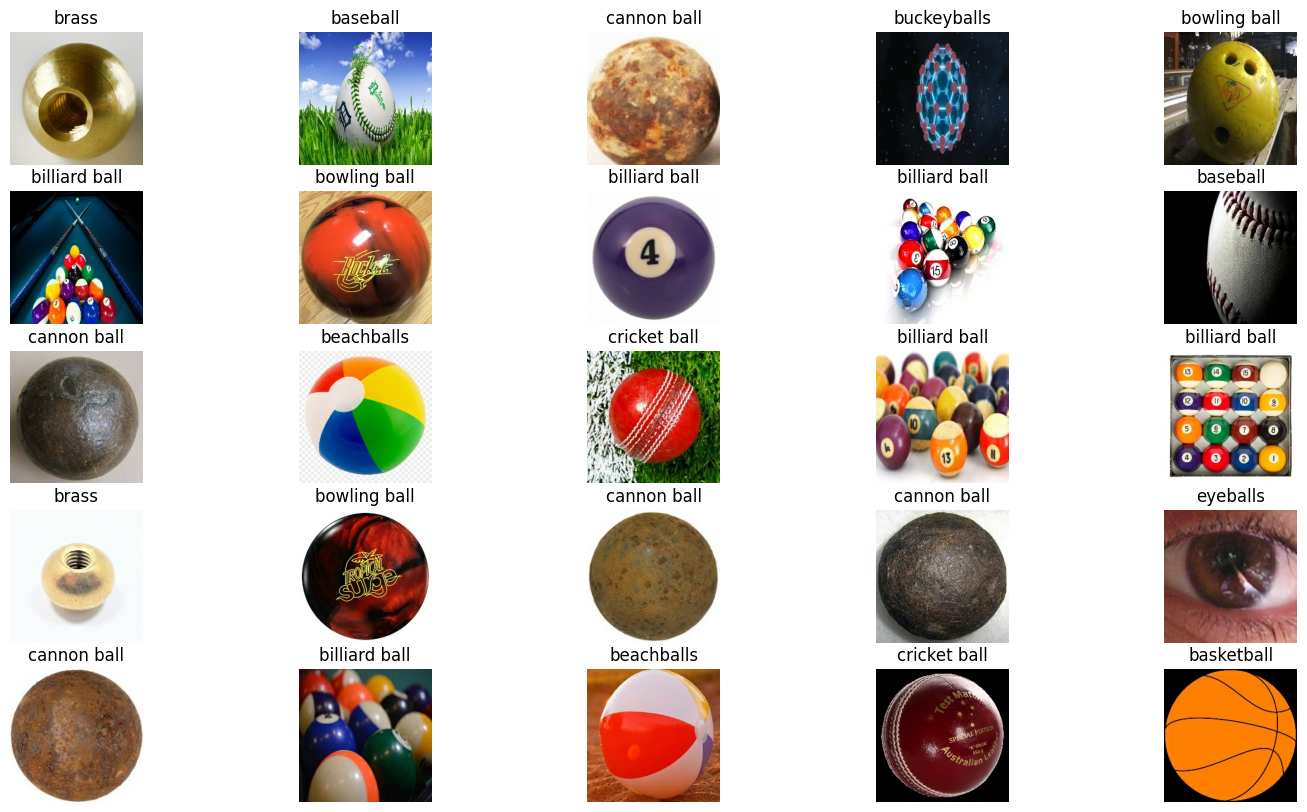

In [7]:
classNames = train_dataset.class_names

plt.figure(figsize=(18, 10))
numRows = 5
numCols = 5

for imagesBatch, labelsBatch in train_dataset.take(1):
    for i in range(numRows * numCols):
        ax = plt.subplot(numRows, numCols, i + 1)
        plt.imshow(imagesBatch[i].numpy().astype("uint8"))
        truthIndex = np.nonzero(labelsBatch[i].numpy())
        plt.title(classNames[truthIndex[0][0]])
        plt.axis("off")

plt.show()

### Compile and train the model

In [8]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=TrainingConfig.LEARNING_RATE),
    loss=keras.losses.CategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"],
)

modelCheckpointCallback = keras.callbacks.ModelCheckpoint(
    filepath=TrainingConfig.CHECKPOINT_PATH,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    save_weights_only=False,
)

trainingResults = model.fit(
    train_dataset,
    epochs=TrainingConfig.EPOCHS,
    callbacks=modelCheckpointCallback,
    validation_data=valid_dataset,
)

Epoch 1/21
36/36 ━━━━━━━━━━━━━━━━━━━━ 672s 17s/step - accuracy: 0.1236 - loss: 44.6821 - val_accuracy: 0.0800 - val_loss: 2.3008
Epoch 2/21
36/36 ━━━━━━━━━━━━━━━━━━━━ 864s 25s/step - accuracy: 0.1698 - loss: 2.2371 - val_accuracy: 0.1950 - val_loss: 2.1501
Epoch 3/21
36/36 ━━━━━━━━━━━━━━━━━━━━ 172s 5s/step - accuracy: 0.2542 - loss: 2.0899 - val_accuracy: 0.2900 - val_loss: 1.9775
Epoch 4/21
36/36 ━━━━━━━━━━━━━━━━━━━━ 215s 6s/step - accuracy: 0.3280 - loss: 1.7816 - val_accuracy: 0.2300 - val_loss: 1.9374
Epoch 5/21
36/36 ━━━━━━━━━━━━━━━━━━━━ 218s 6s/step - accuracy: 0.4009 - loss: 1.6521 - val_accuracy: 0.3450 - val_loss: 1.9162
Epoch 6/21
36/36 ━━━━━━━━━━━━━━━━━━━━ 205s 6s/step - accuracy: 0.4800 - loss: 1.4456 - val_accuracy: 0.3800 - val_loss: 1.6618
Epoch 7/21
36/36 ━━━━━━━━━━━━━━━━━━━━ 213s 6s/step - accuracy: 0.5689 - loss: 1.2658 - val_accuracy: 0.4500 - val_loss: 1.5787
Epoch 8/21
36/36 ━━━━━━━━━━━━━━━━━━━━ 217s 6s/step - accuracy: 0.6320 - loss: 1.0556 - val_accuracy: 0.5000 

In [9]:
def plotMetrics(metrics, metricsName=None, yLabel=None, yLim=None, colours=None):
    if not (isinstance(metricsName, list) or isinstance(metricsName, tuple)):
        metricsName = [
            metricsName,
        ]
        metric = [
            metrics,
        ]
        colours = [
            colours,
        ]

    plt.figure(figsize=(15, 4))

    for idx, metric in enumerate(metrics):
        plt.plot(metric, color=colours[idx], label=metricsName[idx])

    plt.xlabel = "Epoch"
    plt.xlim(0, TrainingConfig.EPOCHS - 1)
    plt.ylabel = yLabel
    plt.ylim(yLim)
    plt.title(yLabel)
    plt.grid(True)

    ax.xaxis.set_major_locator(MultipleLocator(5))
    ax.xaxis.set_major_formatter(FormatStrFormatter("%d"))
    ax.xaxis.set_minor_locator(MultipleLocator(1))

    plt.show(block=False)
    plt.close()

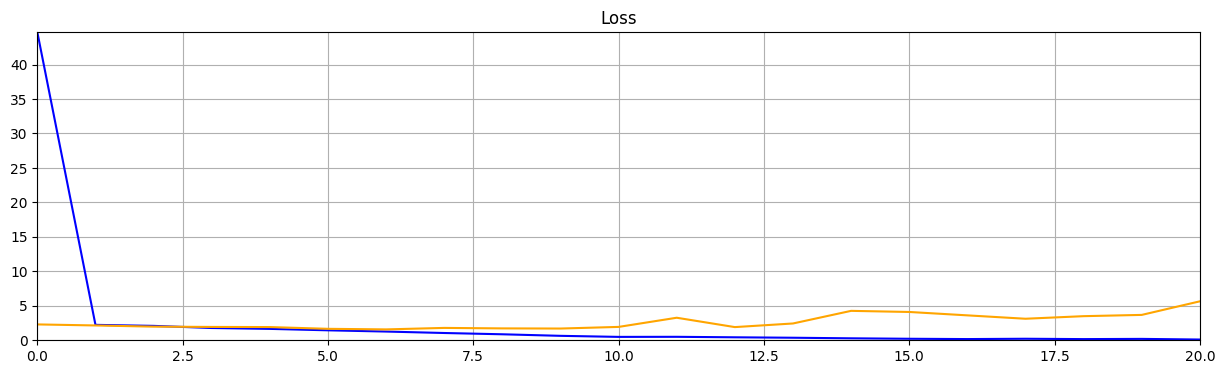

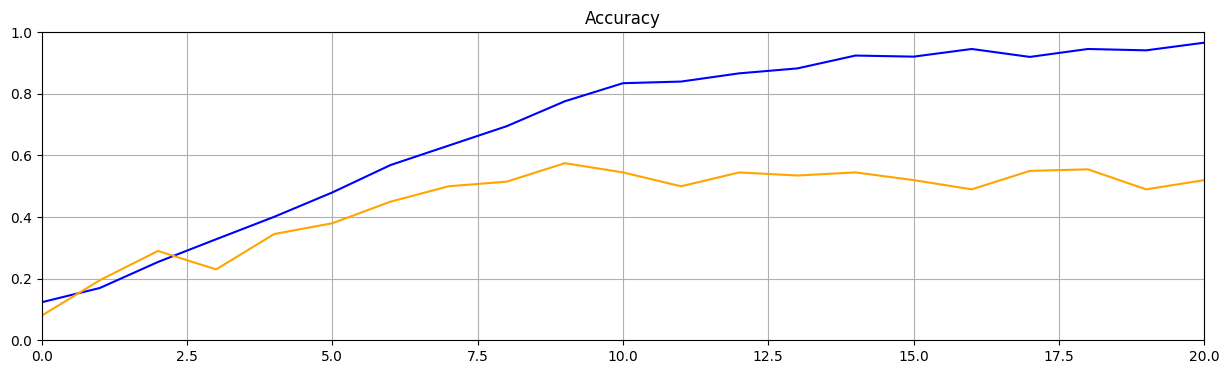

In [10]:
loss = trainingResults.history["loss"]
val_loss = trainingResults.history["val_loss"]
accuracy = trainingResults.history["accuracy"]
val_accuracy = trainingResults.history["val_accuracy"]

plotMetrics(
    [loss, val_loss],
    ["Training Loss", "Validation Loss"],
    yLabel="Loss",
    yLim=(0, max(max(loss), max(val_loss))),
    colours=["blue", "orange"],
)
plotMetrics(
    [accuracy, val_accuracy],
    ["Training Accuracy", "Validation Accuracy"],
    yLabel="Accuracy",
    yLim=(0, 1.0),
    colours=["blue", "orange"],
)

### Model Evaluation

In [12]:
savedModel = keras.models.load_model(TrainingConfig.CHECKPOINT_PATH)
print("Loaded best model from checkpoint.")
savedModel.evaluate(valid_dataset)[1] * 100

Loaded best model from checkpoint.
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.5750 - loss: 1.7023


57.499998807907104

In [17]:
def display_wrong_predictions(model, dataset):
    plt.figure(figsize=(20, 15))
    numRows = 4
    numCols = 5
    jdx = 0

    for image_batch, labels_batch in dataset:
        predictions = model.predict(image_batch)

        # Loop over all the images in the current batch.
        for idx in range(len(labels_batch)):
            pred_idx = tf.argmax(predictions[idx]).numpy()
            truth_idx = np.nonzero(labels_batch[idx].numpy())

            # Plot the images with incorrect predictions
            if pred_idx != truth_idx:
                jdx += 1

                if jdx > numRows * numCols:
                    # Break from the loops if the maximum number of images have been plotted
                    break

                ax = plt.subplot(numRows, numCols, jdx)
                title = (
                    str(classNames[truth_idx[0][0]]) + " : " + str(classNames[pred_idx])
                )
                title_obj = plt.title(title)
                plt.setp(title_obj, color="r")
                plt.axis("off")
                plt.imshow(image_batch[idx].numpy().astype("uint8"))
    return

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step


2025-11-29 14:37:06.830215: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


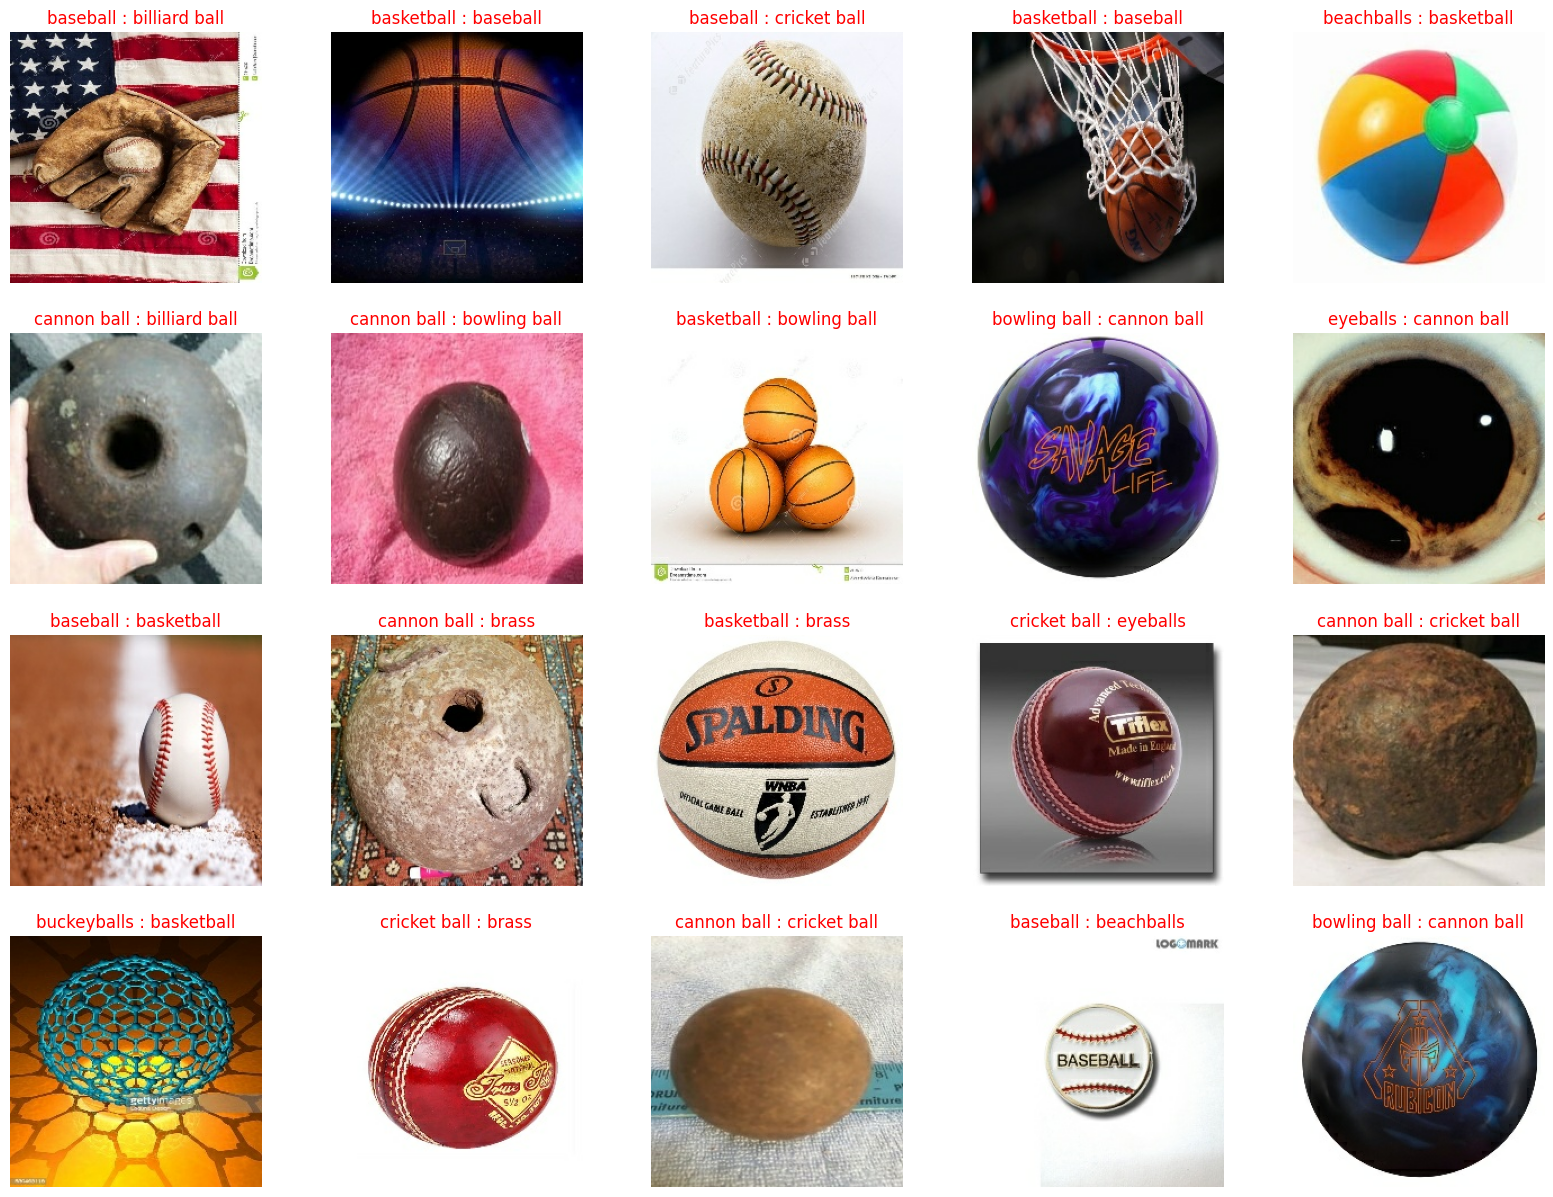

In [18]:
display_wrong_predictions(savedModel, valid_dataset)